In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from scipy.signal import resample_poly
from pathlib import Path
import os

# ── project root ───────────────────────────────────────────────
# Works regardless of how many times the cell is re-run
notebook_dir = Path(os.getcwd())
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")

# ── paths ──────────────────────────────────────────────────────
DATA_DIR = Path("data/raw/eegdenoisenet/data")
FIG_DIR  = Path("results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── matplotlib defaults ────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#161b27",
    "axes.edgecolor":   "#2a3045",
    "text.color":       "#e4e8f4",
    "axes.labelcolor":  "#e4e8f4",
    "xtick.color":      "#7a849e",
    "ytick.color":      "#7a849e",
    "grid.color":       "#2a3045",
    "grid.alpha":       0.6,
    "font.family":      "monospace",
    "figure.dpi":       120,
})

print("✅ Imports OK")
print(f"   DATA_DIR exists: {DATA_DIR.exists()}")
print(f"   Files: {sorted(os.listdir(DATA_DIR))}")

Working directory: /Users/yago.velazquez/eeg_pipeline
✅ Imports OK
   DATA_DIR exists: True
   Files: ['EEG_all_epochs.npy', 'EEG_all_epochs_512hz.npy', 'EMG_all_epochs.npy', 'EMG_all_epochs_512hz.npy', 'EOG_all_epochs.npy']


In [31]:
# ── load 256 Hz arrays ─────────────────────────────────────────
eeg_clean = np.load(DATA_DIR / "EEG_all_epochs.npy")
eog_noise = np.load(DATA_DIR / "EOG_all_epochs.npy")
emg_noise = np.load(DATA_DIR / "EMG_all_epochs.npy")

# ── load 512 Hz arrays (for correct EMG synthesis) ─────────────
eeg_512hz = np.load(DATA_DIR / "EEG_all_epochs_512hz.npy")
emg_512hz = np.load(DATA_DIR / "EMG_all_epochs_512hz.npy")

# ── shapes ─────────────────────────────────────────────────────
for name, arr in [("EEG clean (256 Hz)",  eeg_clean),
                  ("EOG noise (256 Hz)",  eog_noise),
                  ("EMG noise (256 Hz)",  emg_noise),
                  ("EEG 512 Hz",          eeg_512hz),
                  ("EMG 512 Hz",          emg_512hz)]:
    print(f"\n{name}")
    print(f"  shape : {arr.shape}")
    print(f"  dtype : {arr.dtype}")
    print(f"  min   : {arr.min():.4f}  max: {arr.max():.4f}")
    print(f"  mean  : {arr.mean():.4f}  std: {arr.std():.4f}")
    print(f"  NaNs  : {np.isnan(arr).sum()}")


EEG clean (256 Hz)
  shape : (4514, 512)
  dtype : float64
  min   : -1684.6420  max: 1798.9493
  mean  : -0.0137  std: 228.5519
  NaNs  : 0

EOG noise (256 Hz)
  shape : (3400, 512)
  dtype : float64
  min   : -1226.9343  max: 1182.9502
  mean  : 0.0729  std: 154.4632
  NaNs  : 0

EMG noise (256 Hz)
  shape : (5598, 512)
  dtype : float64
  min   : -1304139.7926  max: 1363045.1702
  mean  : 56.5702  std: 33264.0813
  NaNs  : 0

EEG 512 Hz
  shape : (4514, 1024)
  dtype : float64
  min   : -1684.2811  max: 1822.9314
  mean  : -0.0144  std: 228.5484
  NaNs  : 0

EMG 512 Hz
  shape : (5598, 1024)
  dtype : float64
  min   : -1585360.6664  max: 1968404.8251
  mean  : 56.8743  std: 40618.9251
  NaNs  : 0


In [32]:
# Only run this cell if shapes printed as 3D (e.g. (4514, 1, 512))
if eeg_clean.ndim == 3:
    eeg_clean = eeg_clean.squeeze(1)
    eog_noise = eog_noise.squeeze(1)
    emg_noise = emg_noise.squeeze(1)
    print("Squeezed to 2D:", eeg_clean.shape, eog_noise.shape, emg_noise.shape)
else:
    print("Arrays are already 2D — no squeeze needed")

if eeg_512hz.ndim == 3:
    eeg_512hz = eeg_512hz.squeeze(1)
    emg_512hz = emg_512hz.squeeze(1)
    print("512 Hz arrays squeezed to 2D:", eeg_512hz.shape, emg_512hz.shape)
else:
    print("512 Hz arrays already 2D — no squeeze needed")

Arrays are already 2D — no squeeze needed
512 Hz arrays already 2D — no squeeze needed


In [33]:
# ── 256 Hz arrays ──────────────────────────────────────────────
FS      = 256
N_SAMP  = eeg_clean.shape[1]
EPOCH_S = N_SAMP / FS

print(f"=== 256 Hz arrays ===")
print(f"Sampling rate    : {FS} Hz")
print(f"Samples / epoch  : {N_SAMP}")
print(f"Epoch duration   : {EPOCH_S:.2f} s")

print(f"\nPer-epoch std (EEG clean 256 Hz):")
epoch_stds = eeg_clean.std(axis=1)
print(f"  mean std across epochs : {epoch_stds.mean():.4f}")
print(f"  min / max epoch std    : {epoch_stds.min():.4f} / {epoch_stds.max():.4f}")

already_normalised = epoch_stds.mean() < 5
print(f"\nData appears normalised : {already_normalised}")
print("  → dataset.py will z-score per-epoch regardless")

# ── 512 Hz arrays ──────────────────────────────────────────────
FS_512      = 512
N_SAMP_512  = eeg_512hz.shape[1]
EPOCH_S_512 = N_SAMP_512 / FS_512

print(f"\n=== 512 Hz arrays ===")
print(f"Sampling rate    : {FS_512} Hz")
print(f"Samples / epoch  : {N_SAMP_512}")
print(f"Epoch duration   : {EPOCH_S_512:.2f} s")

print(f"\nPer-epoch std (EEG 512 Hz):")
epoch_stds_512 = eeg_512hz.std(axis=1)
print(f"  mean std across epochs : {epoch_stds_512.mean():.4f}")
print(f"  min / max epoch std    : {epoch_stds_512.min():.4f} / {epoch_stds_512.max():.4f}")

print(f"\nPer-epoch std (EMG 512 Hz):")
emg_stds_512 = emg_512hz.std(axis=1)
print(f"  mean std across epochs : {emg_stds_512.mean():.4f}")
print(f"  min / max epoch std    : {emg_stds_512.min():.4f} / {emg_stds_512.max():.4f}")

print(f"\nEMG/EEG std ratio (512 Hz): {emg_stds_512.mean() / epoch_stds_512.mean():.1f}x")
print("  → mix_snr() per-epoch RMS scaling will handle this automatically")

=== 256 Hz arrays ===
Sampling rate    : 256 Hz
Samples / epoch  : 512
Epoch duration   : 2.00 s

Per-epoch std (EEG clean 256 Hz):
  mean std across epochs : 218.8283
  min / max epoch std    : 63.2286 / 502.7818

Data appears normalised : False
  → dataset.py will z-score per-epoch regardless

=== 512 Hz arrays ===
Sampling rate    : 512 Hz
Samples / epoch  : 1024
Epoch duration   : 2.00 s

Per-epoch std (EEG 512 Hz):
  mean std across epochs : 218.8270
  min / max epoch std    : 63.2380 / 503.2495

Per-epoch std (EMG 512 Hz):
  mean std across epochs : 17298.4726
  min / max epoch std    : 770.0931 / 408680.2925

EMG/EEG std ratio (512 Hz): 79.1x
  → mix_snr() per-epoch RMS scaling will handle this automatically


In [34]:
def mix_snr(clean_epoch, noise_epoch, snr_db=0):
    """Mix one clean epoch with one noise epoch at a given SNR (dB).
    
    Args:
        clean_epoch : 1D array, shape (n_samples,)
        noise_epoch : 1D array, shape (n_samples,)
        snr_db      : target SNR in dB (0 = equal power)
    Returns:
        noisy : 1D array, same shape
    """
    snr_linear = 10 ** (snr_db / 20)
    clean_std  = clean_epoch.std() + 1e-8
    noise_std  = noise_epoch.std() + 1e-8
    alpha      = clean_std / (snr_linear * noise_std)
    return clean_epoch + alpha * noise_epoch


# Quick test
rng    = np.random.default_rng(42)
ci, ni = rng.integers(0, len(eeg_clean)), rng.integers(0, len(eog_noise))
test_n = mix_snr(eeg_clean[ci], eog_noise[ni], snr_db=0)

ratio  = eeg_clean[ci].std() / test_n.std()
print(f"Mix test — clean_std / noisy_std = {ratio:.3f} (expect ~0.7 at 0 dB)")

Mix test — clean_std / noisy_std = 0.672 (expect ~0.7 at 0 dB)


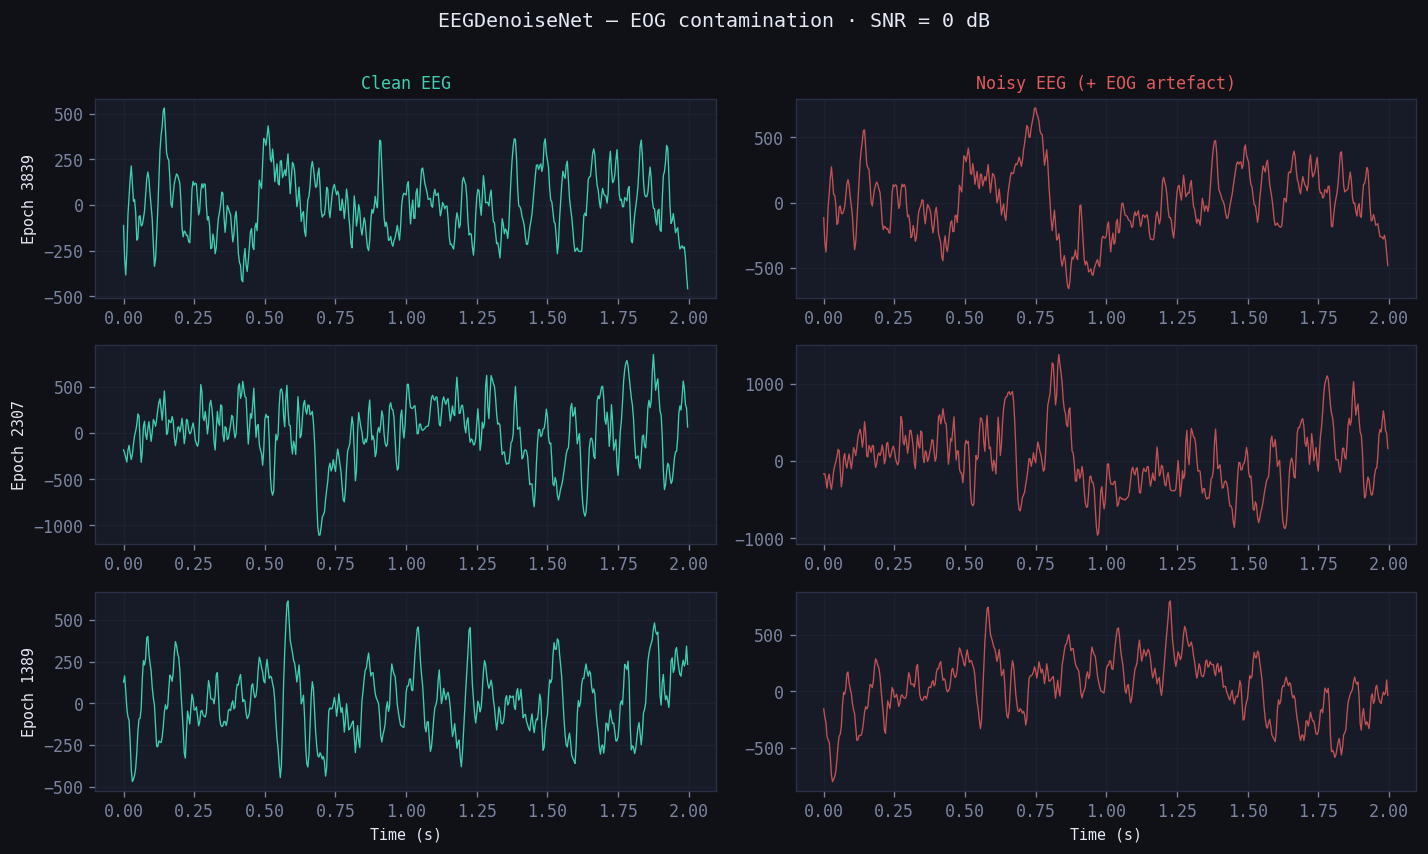

✅ Saved: results/figures/denoiser_eog_pairs.png


In [35]:
rng   = np.random.default_rng(0)
N_EX  = 3
t_ax  = np.arange(N_SAMP) / FS        # time axis in seconds

fig, axes = plt.subplots(N_EX, 2, figsize=(12, 7), sharey=False)
fig.suptitle("EEGDenoiseNet — EOG contamination · SNR = 0 dB", 
             fontsize=12, y=1.01)

for i in range(N_EX):
    ci = rng.integers(0, len(eeg_clean))
    ni = rng.integers(0, len(eog_noise))
    
    clean = eeg_clean[ci]
    noisy = mix_snr(clean, eog_noise[ni], snr_db=0)
    
    # clean
    axes[i, 0].plot(t_ax, clean, color="#3ecfb2", lw=0.8)
    axes[i, 0].set_ylabel(f"Epoch {ci}", fontsize=9)
    axes[i, 0].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 0].set_title("Clean EEG", fontsize=10, color="#3ecfb2")
    
    # noisy
    axes[i, 1].plot(t_ax, noisy, color="#e05c5c", lw=0.8, alpha=0.85)
    axes[i, 1].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 1].set_title("Noisy EEG (+ EOG artefact)", fontsize=10, color="#e05c5c")
    if i == N_EX - 1:
        axes[i, 0].set_xlabel("Time (s)", fontsize=9)
        axes[i, 1].set_xlabel("Time (s)", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "denoiser_eog_pairs.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"✅ Saved: {FIG_DIR}/denoiser_eog_pairs.png")

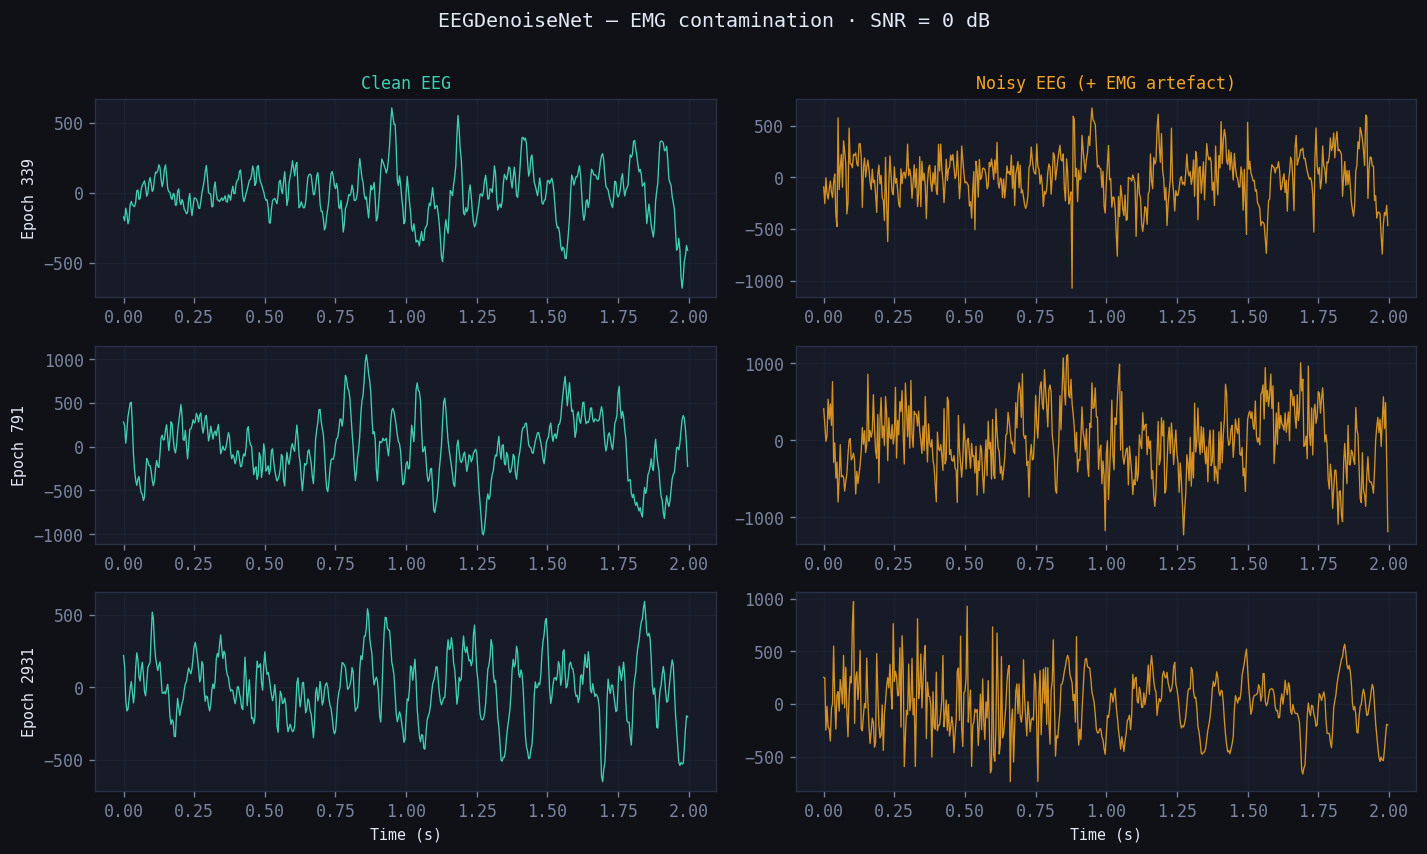

✅ Saved: results/figures/denoiser_emg_pairs.png


In [36]:
# Time axis stays at 256 Hz for plotting
t_ax_256 = np.arange(N_SAMP) / FS

fig, axes = plt.subplots(N_EX, 2, figsize=(12, 7), sharey=False)
fig.suptitle("EEGDenoiseNet — EMG contamination · SNR = 0 dB",
             fontsize=12, y=1.01)

for i in range(N_EX):
    ci = rng.integers(0, len(eeg_512hz))
    ni = rng.integers(0, len(emg_512hz))

    # Mix at 512 Hz — both arrays are (n_epochs, 1024), same rate, same duration
    clean_512 = eeg_512hz[ci]
    noisy_512 = mix_snr(clean_512, emg_512hz[ni], snr_db=0)

    # Downsample both to 256 Hz for plotting
    clean_256 = resample_poly(clean_512, up=1, down=2)
    noisy_256 = resample_poly(noisy_512, up=1, down=2)

    axes[i, 0].plot(t_ax_256, clean_256, color="#3ecfb2", lw=0.8)
    axes[i, 0].set_ylabel(f"Epoch {ci}", fontsize=9)
    axes[i, 0].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 0].set_title("Clean EEG", fontsize=10, color="#3ecfb2")

    axes[i, 1].plot(t_ax_256, noisy_256, color="#f5a623", lw=0.8, alpha=0.85)
    axes[i, 1].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 1].set_title("Noisy EEG (+ EMG artefact)", fontsize=10, color="#f5a623")
    if i == N_EX - 1:
        axes[i, 0].set_xlabel("Time (s)", fontsize=9)
        axes[i, 1].set_xlabel("Time (s)", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "denoiser_emg_pairs.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"✅ Saved: {FIG_DIR}/denoiser_emg_pairs.png")

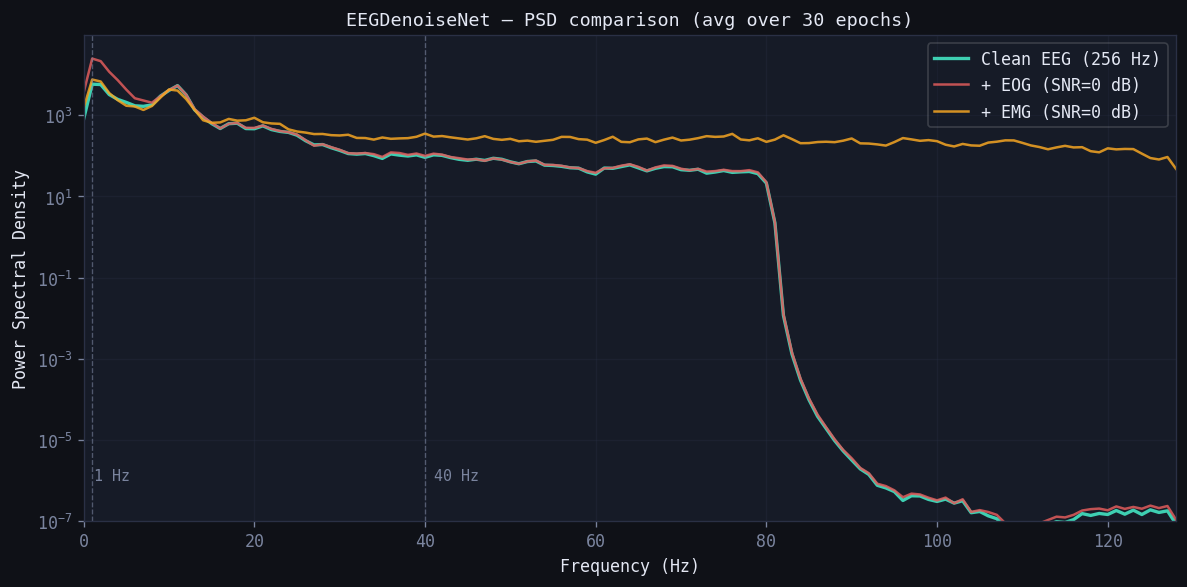

✅ Saved: results/figures/denoiser_psd_comparison.png


In [37]:
rng = np.random.default_rng(99)
N_AVG = 30   # average PSDs across this many epochs for smooth curves

psd_clean     = []
psd_eog_noisy = []
psd_emg_noisy = []

for _ in range(N_AVG):
    ci   = rng.integers(0, len(eeg_clean))
    ni_e = rng.integers(0, len(eog_noise))
    ni_m = rng.integers(0, len(emg_512hz))

    # EOG — mix at 256 Hz directly
    clean   = eeg_clean[ci]
    n_eog   = mix_snr(clean, eog_noise[ni_e], snr_db=0)

    # EMG — mix at 512 Hz, downsample to 256 Hz
    ci_512  = rng.integers(0, len(eeg_512hz))
    n_emg_512 = mix_snr(eeg_512hz[ci_512], emg_512hz[ni_m], snr_db=0)
    n_emg   = resample_poly(n_emg_512, up=1, down=2)

    f,    pc = signal.welch(clean,  FS,  nperseg=256)
    _,    pe = signal.welch(n_eog,  FS,  nperseg=256)
    _,    pm = signal.welch(n_emg,  FS,  nperseg=256)

    psd_clean.append(pc)
    psd_eog_noisy.append(pe)
    psd_emg_noisy.append(pm)

psd_clean     = np.array(psd_clean).mean(axis=0)
psd_eog_noisy = np.array(psd_eog_noisy).mean(axis=0)
psd_emg_noisy = np.array(psd_emg_noisy).mean(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(f, psd_clean,     color="#3ecfb2", lw=2,   label="Clean EEG (256 Hz)")
ax.semilogy(f, psd_eog_noisy, color="#e05c5c", lw=1.5, label="+ EOG (SNR=0 dB)", alpha=0.85)
ax.semilogy(f, psd_emg_noisy, color="#f5a623", lw=1.5, label="+ EMG (SNR=0 dB)", alpha=0.85)

ax.set_xlim(0, 128)
ax.set_ylim(bottom=1e-7)

y_text = ax.get_ylim()[0] * 10

ax.axvline(1,  color="#7a849e", lw=0.8, ls="--", alpha=0.6)
ax.axvline(40, color="#7a849e", lw=0.8, ls="--", alpha=0.6)
ax.text(1.2, y_text, "1 Hz",  color="#7a849e", fontsize=9)
ax.text(41,  y_text, "40 Hz", color="#7a849e", fontsize=9)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density")
ax.set_title("EEGDenoiseNet — PSD comparison (avg over 30 epochs)", fontsize=11)
ax.legend(framealpha=0.2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "denoiser_psd_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"✅ Saved: {FIG_DIR}/denoiser_psd_comparison.png")

## Architectural constraint — why joint pipeline evaluation is future work

**EEGDenoiseNet is single-channel.** Each epoch contains exactly one EEG channel with no
electrode montage, no spatial relationships between channels, and no quality annotations.

The BCR component (XGBoost classifier) relies on:
- Spatial correlation features between adjacent electrodes
- Per-channel impedance measurements across the full montage
- Multi-channel statistical comparisons (e.g. variance relative to neighbouring channels)

None of these features can be computed from a single-channel dataset.

**Consequence for this project:**
- BCR is validated independently on the labeled feature table (18,900 rows, 43 subjects, 4 sites)
- Denoiser is validated independently on EEGDenoiseNet (single-channel, synthetic artifacts)
- The interface contract between BCR and denoiser is written as a **design specification**,
  not tested at runtime in this submission

**Future work candidate:**
PhysioNet EEG-MMI (109 subjects, 64 ch, 10-20 montage) provides the spatial structure
needed for joint evaluation. This is documented in `report/future_work_draft.md`.

In [29]:
eeg_512 = np.load(DATA_DIR / "EEG_all_epochs_512hz.npy")
emg_512 = np.load(DATA_DIR / "EMG_all_epochs_512hz.npy")

for name, arr in [("EEG 512hz", eeg_512), ("EMG 512hz", emg_512)]:
    print(f"\n{name}")
    print(f"  shape : {arr.shape}")
    print(f"  dtype : {arr.dtype}")
    print(f"  std   : {arr.std():.4f}")
    print(f"  NaNs  : {np.isnan(arr).sum()}")


EEG 512hz
  shape : (4514, 1024)
  dtype : float64
  std   : 228.5484
  NaNs  : 0

EMG 512hz
  shape : (5598, 1024)
  dtype : float64
  std   : 40618.9251
  NaNs  : 0
